In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [85]:
economy_df = pd.read_csv('economy.csv')
business_df = pd.read_csv('business.csv')
clean_df = pd.read_csv('Clean_Dataset.csv')

In [86]:
print("economy.csv info:")
economy_df.info()
print("economy.csv head:")
display(economy_df.head())

print("\nbusiness.csv info:")
business_df.info()
print("\nbusiness.csv head:")
display(business_df.head())

print("\nClean_Dataset.csv info:")
clean_df.info()
print("\nClean_Dataset.csv head:")
display(clean_df.head())

economy.csv info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     206774 non-null  object
 3   num_code    206774 non-null  int64 
 4   dep_time    206774 non-null  object
 5   from        206774 non-null  object
 6   time_taken  206774 non-null  object
 7   stop        206774 non-null  object
 8   arr_time    206774 non-null  object
 9   to          206774 non-null  object
 10  price       206774 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.4+ MB
economy.csv head:


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"



business.csv info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        93487 non-null  object
 1   airline     93487 non-null  object
 2   ch_code     93487 non-null  object
 3   num_code    93487 non-null  int64 
 4   dep_time    93487 non-null  object
 5   from        93487 non-null  object
 6   time_taken  93487 non-null  object
 7   stop        93487 non-null  object
 8   arr_time    93487 non-null  object
 9   to          93487 non-null  object
 10  price       93487 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB

business.csv head:


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"



Clean_Dataset.csv info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB

Clean_Dataset.csv head:


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


проверка на пропуски

In [87]:
print("пропуски в economy.csv:")
print(economy_df.isnull().sum())
print("\nпропуски в business.csv:")
print(business_df.isnull().sum())
print("\nпропуски в Clean_Dataset.csv:")
print(clean_df.isnull().sum())

пропуски в economy.csv:
date          0
airline       0
ch_code       0
num_code      0
dep_time      0
from          0
time_taken    0
stop          0
arr_time      0
to            0
price         0
dtype: int64

пропуски в business.csv:
date          0
airline       0
ch_code       0
num_code      0
dep_time      0
from          0
time_taken    0
stop          0
arr_time      0
to            0
price         0
dtype: int64

пропуски в Clean_Dataset.csv:
Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


приведение времени к единому формату

In [89]:
def parse_duration(duration_str):
    if isinstance(duration_str, str):
        parts = duration_str.replace('h', '').replace('m', '').split()
        hours = 0
        minutes = 0
        for part in parts:
            if 'h' in duration_str and part.isdigit():
                hours = int(part) if 'h' in duration_str else 0
            elif 'm' in duration_str and part.isdigit():
                minutes = int(part) if 'm' in duration_str else 0
        return hours + minutes / 60.0
    return np.nan

def categorize_departure(hour):
    if hour < 6:
        return 'night'
    elif hour < 12:
        return 'morning'
    elif hour < 18:
        return 'afternoon'
    else:
        return 'evening'

In [90]:
economy_df['duration_hours'] = economy_df['time_taken'].apply(parse_duration)
business_df['duration_hours'] = business_df['time_taken'].apply(parse_duration)

economy_df['dep_hour'] = pd.to_datetime(economy_df['dep_time'], format='%H:%M').dt.hour
business_df['dep_hour'] = pd.to_datetime(business_df['dep_time'], format='%H:%M').dt.hour

economy_df['departure_period'] = economy_df['dep_hour'].apply(categorize_departure)
business_df['departure_period'] = business_df['dep_hour'].apply(categorize_departure)

economy_df['class'] = 'economy'
business_df['class'] = 'business'

economy_df['date'] = pd.to_datetime(economy_df['date'], format='%d-%m-%Y')
business_df['date'] = pd.to_datetime(business_df['date'], format='%d-%m-%Y')

объединение данных

stop_dummy = 1/0 (есть пересадка/нет пересадки)

In [91]:
economy_df['stop_dummy'] = (economy_df['stop'] != 'non-stop').astype(int)
business_df['stop_dummy'] = (business_df['stop'] != 'non-stop').astype(int)

analysis_df = pd.concat([economy_df, business_df], ignore_index=True)
print(f"объединенный датасет: {analysis_df.shape[0]} строк")
print(f"колонки: {analysis_df.columns.tolist()}")


объединенный датасет: 300261 строк
колонки: ['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from', 'time_taken', 'stop', 'arr_time', 'to', 'price', 'duration_hours', 'dep_hour', 'departure_period', 'class', 'stop_dummy']


In [92]:
analysis_df['stop_clean'] = analysis_df['stop'].astype(str).str.replace('\n', '').str.replace('\t', '').str.strip()

def categorize_stop(val):
    if 'non-stop' in val:
        return 'non-stop'
    elif '2+' in val or '2-stop' in val:
        return '2-stop'
    elif '1-stop' in val:
        return '1-stop'
    else:
        return 'other'

analysis_df['stop_clean'] = analysis_df['stop_clean'].apply(categorize_stop)

print("уникальные значения stop_clean:")
print(analysis_df['stop_clean'].value_counts())

analysis_df['stop_dummy'] = (analysis_df['stop_clean'] != 'non-stop').astype(int)

analysis_df['price'] = analysis_df['price'].str.replace(',', '').astype(float)
analysis_df['log_price'] = np.log(analysis_df['price'])

analysis_df.head()

уникальные значения stop_clean:
stop_clean
1-stop      250929
non-stop     36044
2-stop       13288
Name: count, dtype: int64


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,duration_hours,dep_hour,departure_period,class,stop_dummy,stop_clean,log_price
0,2022-02-11,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,5953.0,10.0,18,evening,economy,0,non-stop,8.691651
1,2022-02-11,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,5953.0,20.0,6,morning,economy,0,non-stop,8.691651
2,2022-02-11,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,5956.0,10.0,4,night,economy,0,non-stop,8.692154
3,2022-02-11,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,5955.0,15.0,10,morning,economy,0,non-stop,8.691986
4,2022-02-11,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,5955.0,20.0,8,morning,economy,0,non-stop,8.691986


визуальный анализ

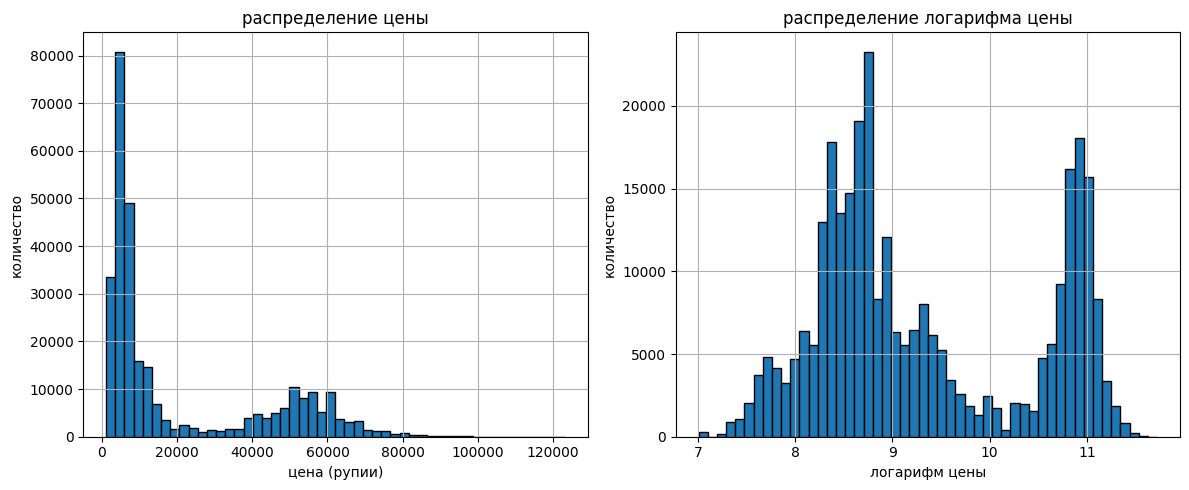

In [71]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
analysis_df['price'].hist(bins=50, edgecolor='black')
plt.title('распределение цены')
plt.xlabel('цена (рупии)')
plt.ylabel('количество')
plt.subplot(1, 2, 2)
analysis_df['log_price'].hist(bins=50, edgecolor='black')
plt.title('распределение логарифма цены')
plt.xlabel('логарифм цены')
plt.ylabel('количество')
plt.tight_layout()
plt.show()

распределение цены:
распределение цены на авиабилеты имеет ярко выраженную правостороннюю асимметрию. основная масса наблюдений сконцентрирована в диапазоне до 20000 рупий, при этом есть длинный хвост в сторону высоких цен вплоть до 100000 рупий. такой характер распределения типичен для цен на товары с сегментированным рынком — наличие бизнес-класса создает отдельную группу дорогих билетов. из-за сильной асимметрии использование цены в исходном виде в качестве зависимой переменной в линейной регрессии приведет к нарушению предпосылки о нормальности остатков.

распределение логарифма цены:
после логарифмирования форма распределения становится значительно ближе к нормальной. пик приходится на значения около 8.5, распределение более симметрично, хотя сохраняется некоторая левосторонняя асимметрия и тяжелые хвосты.

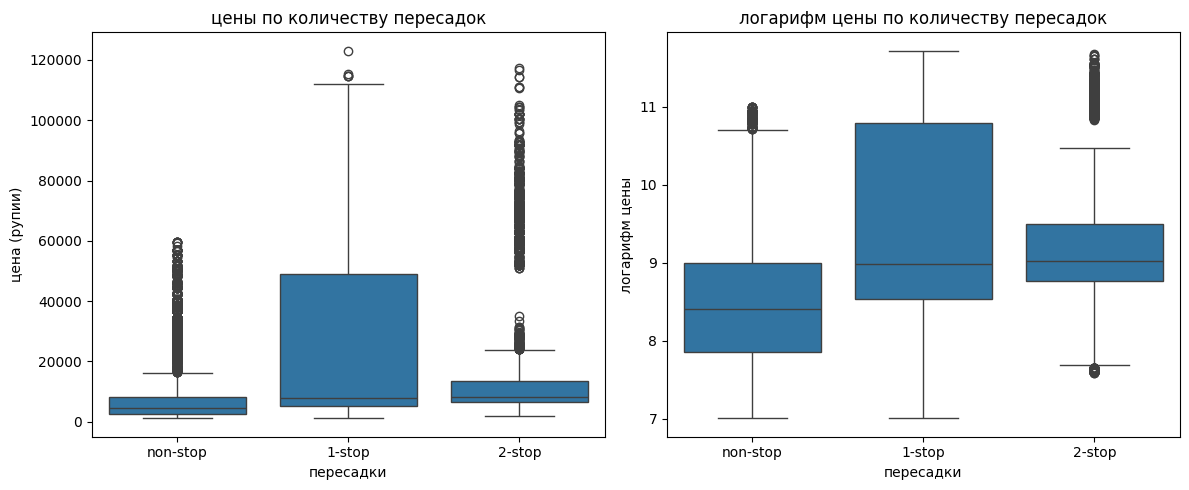

In [93]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='stop_clean', y='price', data=analysis_df, order=['non-stop', '1-stop', '2-stop'])
plt.title('цены по количеству пересадок')
plt.xlabel('пересадки')
plt.ylabel('цена (рупии)')
plt.subplot(1, 2, 2)
sns.boxplot(x='stop_clean', y='log_price', data=analysis_df, order=['non-stop', '1-stop', '2-stop'])
plt.title('логарифм цены по количеству пересадок')
plt.xlabel('пересадки')
plt.ylabel('логарифм цены')
plt.tight_layout()
plt.show()

цены по авиакомпаниям:
наблюдаются существенные различия в ценовой политике авиакомпаний. air india и vistara имеют наиболее высокие медианные цены и широкий межквартильный размах, что говорит о присутствии как эконом, так и бизнес-класса в их предложении. spicejet, airasia, go-first и indigo демонстрируют более низкие медианные цены с компактным распределением — это типичные лоукостеры и бюджетные перевозчики. наличие большого количества выбросов у air india и vistara подтверждает сегментацию на эконом и бизнес-класс. переменная авиакомпании будет важным фактором в модели, так как бренд перевозчика сильно влияет на ценообразование.

цены по количеству пересадок:
рейсы без пересадок имеют наибольший разброс цен — от самых дешевых до самых дорогих билетов. это объясняется тем, что в категории non-stop присутствуют как бюджетные эконом-билеты, так и дорогие бизнес-билеты. стыковочные рейсы часто используются для снижения стоимости дальних направлений. для модели это означает, что переменная пересадок будет значимой, но ее влияние может быть нелинейным и зависеть от других факторов, например, от класса обслуживания.

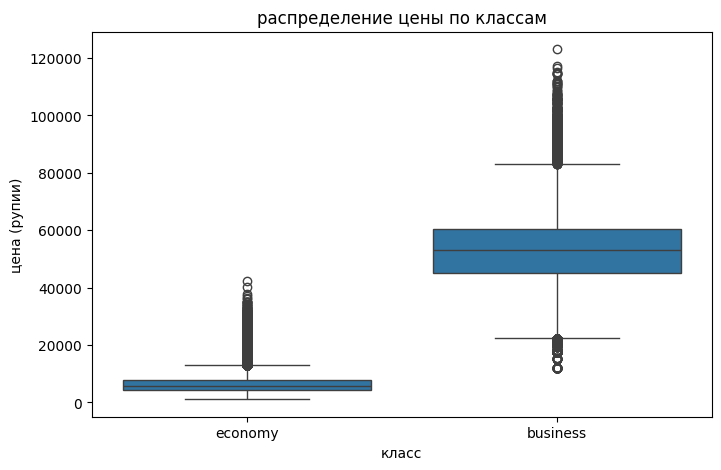

In [74]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='class', y='price', data=analysis_df)
plt.title('распределение цены по классам')
plt.xlabel('класс')
plt.ylabel('цена (рупии)')
plt.show()

распределение цены по классам:
график наглядно демонстрирует фундаментальное разделение рынка авиабилетов на два ценовых сегмента. билеты эконом-класса сконцентрированы в узком диапазоне низких цен с медианой около 5000-10000 рупий, распределение компактное с небольшим количеством выбросов в верхней части. билеты бизнес-класса имеют значительно более высокую медианную цену (около 50000-60000 рупий) и гораздо более широкий разброс, что говорит о неоднородности внутри самого бизнес-сегмента — от относительно доступных бизнес-билетов до премиальных предложений.

ключевые наблюдения:

- распределения практически не пересекаются, что указывает на четкую ценовую границу между классами
- размах цен в бизнес-классе существенно больше, чем в экономе, что может объясняться разной длительностью перелетов, авиакомпаниями и временем вылета
- переменная класса обслуживания будет одним из самых сильных предикторов в модели, вероятно, с наибольшим по модулю коэффициентом


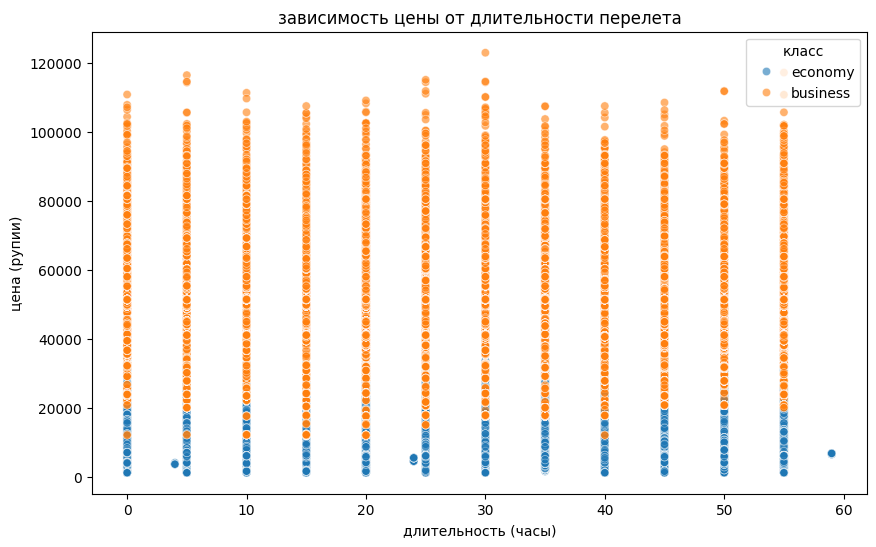

In [75]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_hours', y='price', hue='class', data=analysis_df, alpha=0.6)
plt.title('зависимость цены от длительности перелета')
plt.xlabel('длительность (часы)')
plt.ylabel('цена (рупии)')
plt.legend(title='класс')
plt.show()

зависимость цены от длительности перелета:
график показывает положительную связь между длительностью перелета и ценой билета — чем дольше рейс, тем выше цена. однако характер этой связи различается для двух классов обслуживания. точки эконом-класса образуют плотное облако в нижней части графика, в то время как точки бизнес-класса расположены значительно выше и демонстрируют больший разброс.


- в эконом-классе цена растет с длительностью относительно плавно и предсказуемо, разброс значений увеличивается на дальних рейсах, но остается умеренным
- в бизнес-классе наблюдается значительно больший разброс цен при схожей длительности, особенно на рейсах средней продолжительности (10-20 часов), что может объясняться разными авиакомпаниями, временем вылета и уровнем сервиса
- две группы точек формируют практически параллельные, но смещенные по вертикали облака, что подтверждает аддитивное влияние класса на цену в полулогарифмической модели

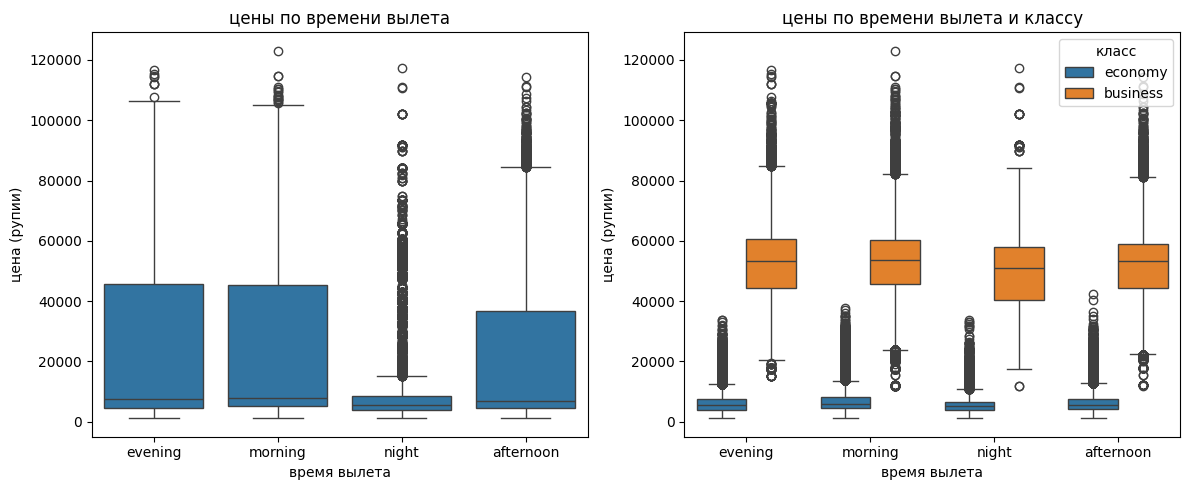

In [76]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='departure_period', y='price', data=analysis_df)
plt.title('цены по времени вылета')
plt.xlabel('время вылета')
plt.ylabel('цена (рупии)')
plt.subplot(1, 2, 2)
sns.boxplot(x='departure_period', y='price', hue='class', data=analysis_df)
plt.title('цены по времени вылета и классу')
plt.xlabel('время вылета')
plt.ylabel('цена (рупии)')
plt.legend(title='класс')
plt.tight_layout()
plt.show()

утренние и ночные рейсы в среднем дешевле, вечерние дороже. эта закономерность сохраняется внутри каждого класса.

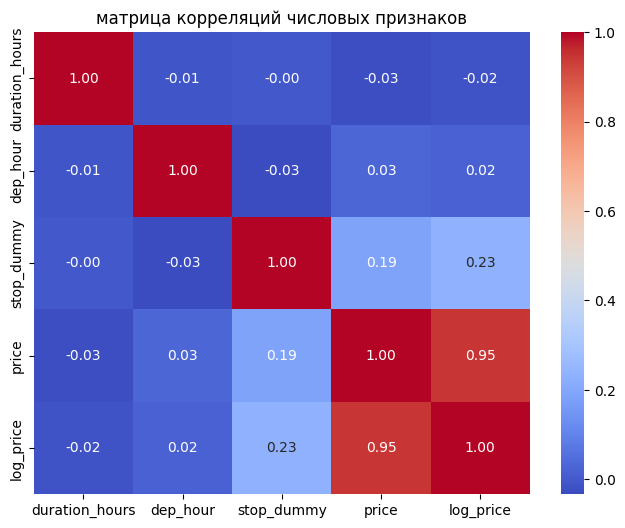

In [77]:
cols_for_corr = ['duration_hours', 'dep_hour', 'stop_dummy', 'price', 'log_price']
corr_df = analysis_df[cols_for_corr].copy()
plt.figure(figsize=(8, 6))
corr_matrix = corr_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('матрица корреляций числовых признаков')
plt.show()

связь с ценой:
логарифм цены имеет заметную положительную корреляцию только с наличием пересадок (0.23), что говорит о том, что стыковочные рейсы в среднем дороже прямых. длительность перелета и час вылета показывают очень слабую линейную связь с ценой — это означает, что их влияние на цену либо нелинейное, либо проявляется только во взаимодействии с другими факторами, такими как класс обслуживания или авиакомпания.

взаимосвязь между признаками:
корреляция между самими числовыми признаками практически отсутствует — Duration _hours, dep_hour и stop_dummy не связаны друг с другом. это хорошо для модели, так как исключает проблему мультиколлинеарности между этими переменными и позволяет оценить их изолированное влияние на цену.

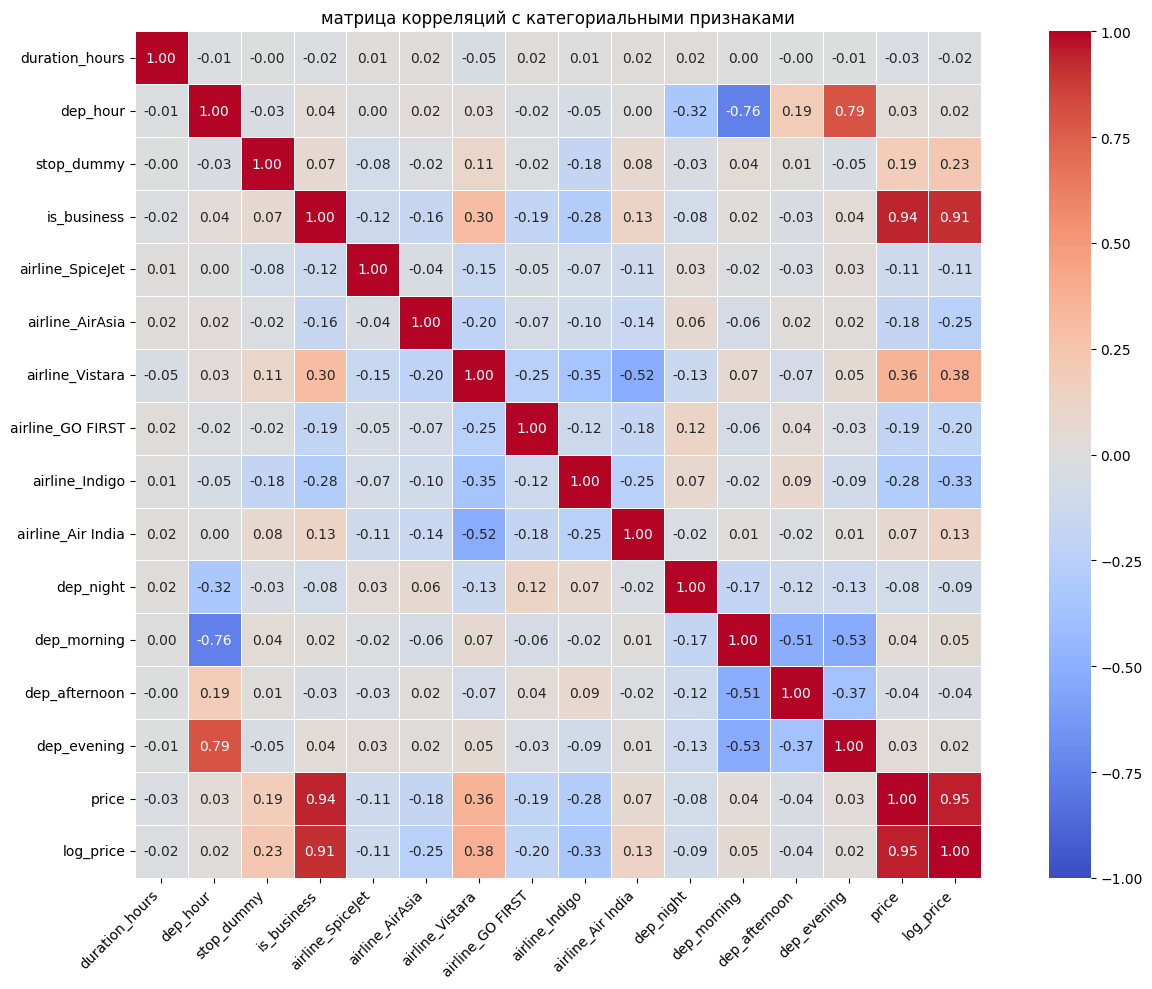

корреляция признаков с логарифмом цены:
log_price            1.000000
price                0.946176
is_business          0.908592
airline_Vistara      0.378753
stop_dummy           0.230863
airline_Air India    0.130795
dep_morning          0.052063
dep_evening          0.020141
dep_hour             0.017417
duration_hours      -0.016081
dep_afternoon       -0.037723
dep_night           -0.092770
airline_SpiceJet    -0.110156
airline_GO FIRST    -0.200196
airline_AirAsia     -0.248755
airline_Indigo      -0.332780
Name: log_price, dtype: float64


In [78]:
analysis_df['is_business'] = (analysis_df['class'] == 'business').astype(int)

top_airlines = analysis_df['airline'].value_counts().head(6).index.tolist()
for airline in top_airlines:
    analysis_df[f'airline_{airline}'] = (analysis_df['airline'] == airline).astype(int)

for period in ['night', 'morning', 'afternoon', 'evening']:
    analysis_df[f'dep_{period}'] = (analysis_df['departure_period'] == period).astype(int)

cols_for_corr = [
    'duration_hours', 'dep_hour', 'stop_dummy', 'is_business',
    'airline_SpiceJet', 'airline_AirAsia', 'airline_Vistara',
    'airline_GO FIRST', 'airline_Indigo', 'airline_Air India',
    'dep_night', 'dep_morning', 'dep_afternoon', 'dep_evening',
    'price', 'log_price'
]

corr_df = analysis_df[cols_for_corr].copy()

plt.figure(figsize=(14, 10))
corr_matrix = corr_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('матрица корреляций с категориальными признаками')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

price_corr = corr_matrix['log_price'].sort_values(ascending=False)
print("корреляция признаков с логарифмом цены:")
print(price_corr)

класс обслуживания — самый сильный предиктор цены, бизнес-класс значительно дороже эконома. наличие пересадок дает умеренную положительную корреляцию с ценой. авиакомпании и время вылета показывают слабую линейную связь с ценой. длительность перелета практически не коррелирует с ценой линейно, но содержательно важна и должна остаться в модели. мультиколлинеарность между признаками отсутствует.

проверка предпосылок ТГМ

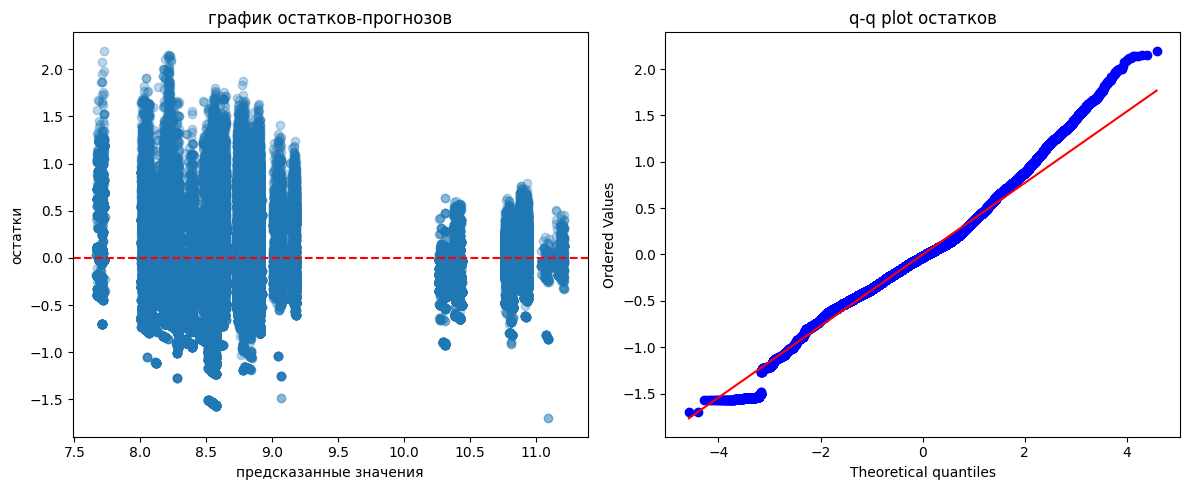

In [94]:
y = analysis_df['log_price']
X = pd.get_dummies(analysis_df[['airline', 'departure_period', 'stop_clean', 'class']], drop_first=True)
X = X.astype(float)
X['duration_hours'] = analysis_df['duration_hours']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(fitted, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('предсказанные значения')
plt.ylabel('остатки')
plt.title('график остатков-прогнозов')
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('q-q plot остатков')
plt.tight_layout()
plt.show()

на левом графике остатков-прогнозов видна выраженная гетероскедастичность — разброс остатков существенно меняется в зависимости от предсказанных значений. в нижней части (предсказанные значения 7.5-8.5, что соответствует эконом-классу) остатки сгруппированы компактно, дисперсия небольшая. в верхней части (9.0-10.5, бизнес-класс) разброс остатков значительно шире, что говорит о неоднородности дисперсии ошибок между классами. также на графике прослеживаются две отдельные группы точек, формирующие почти параллельные полосы — это подтверждает сегментацию данных на эконом и бизнес-класс.

на правом графике q-q plot остатков видно, что распределение остатков отклоняется от нормального на обоих хвостах. точки систематически уходят выше теоретической прямой на правом хвосте и ниже на левом, что указывает на распределение с более тяжелыми хвостами, чем нормальное.

In [95]:
_, bp_pvalue, _, _ = sm.stats.diagnostic.het_breuschpagan(residuals, model.model.exog)
print(f'тест бройша-пагана на гетероскедастичность p-value: {bp_pvalue:.4f}')

jb_stat, jb_pvalue = stats.jarque_bera(residuals)
print(f'тест харке-бера на нормальность остатков p-value: {jb_pvalue:.4f}')

t_stat, t_pvalue = stats.ttest_1samp(residuals, 0)
print(f'тест на нулевое матожидание остатков p-value: {t_pvalue:.4f}')
print(f'среднее остатков: {residuals.mean():.6f}')

print(model.summary())

тест бройша-пагана на гетероскедастичность p-value: 0.0000
тест харке-бера на нормальность остатков p-value: 0.0000
тест на нулевое матожидание остатков p-value: 1.0000
среднее остатков: 0.000000
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                 1.538e+05
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        20:37:15   Log-Likelihood:            -1.4279e+05
No. Observations:              300261   AIC:                         2.856e+05
Df Residuals:                  300246   BIC:                         2.858e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
              

тесты на предпосылки ТГМ:

тест бройша-пагана с p-value = 0.0000 отвергает гомоскедастичность. в данных присутствует гетероскедастичность, что согласуется с визуальным анализом графика остатков-прогнозов.дисперсия ошибок различается для эконом и бизнес-класса.

тест харке-бера с p-value = 0.0000 твергает гипотезу о нормальности распределения остатков. это ожидаемо при таком количестве наблюдений и наличии двух четко разделенных ценовых сегментов.

тест на нулевое матожидание дает p-value = 1.0000 со средним остатков ровно 0 — предпосылка выполняется идеально, модель не дает систематического смещения.

ключевые результаты:

- класс обслуживания остается самым сильным предиктором: коэффициент при class_economy = -2.03 означает, что эконом-билеты дешевле бизнес-класса примерно на 87% при прочих равных.

- авиакомпании показывают значимые различия: vistara дороже базовой air india на 11.9%, airasia дешевле на 43.2%, trujet дешевле на 50.6%. spicejet незначим (p-value = 0.961) и не отличается от air india.

- пересадки имеют четкий эффект: прямые рейсы (non-stop) дешевле рейсов с одной пересадкой на 39.5%, а рейсы с двумя пересадками дороже на 31.5%. это объясняется тем, что прямые рейсы — в основном эконом-класс, а стыковочные чаще включают бизнес-сегмент.

- длительность перелета статистически значима, но экономически малосущественна: дополнительный час увеличивает цену лишь на 0.04%.

- время вылета имеет слабый, но значимый эффект: утренние рейсы дороже дневных на 1.3%, вечерние дешевле на 2.9%, ночные дороже на 1.1%.

общий вывод:

модель адекватна и объясняет 87.8% вариации логарифма цены. основными факторами являются класс обслуживания, авиакомпания и количество пересадок. длительность перелета и время вылета играют второстепенную роль.